In [30]:
from scipy import signal as sig
import numpy as np
import matplotlib.pyplot as plt 
import scipy.io as sio
from scipy.io.wavfile import write

#%matplotlib widget


# CONSIGNA

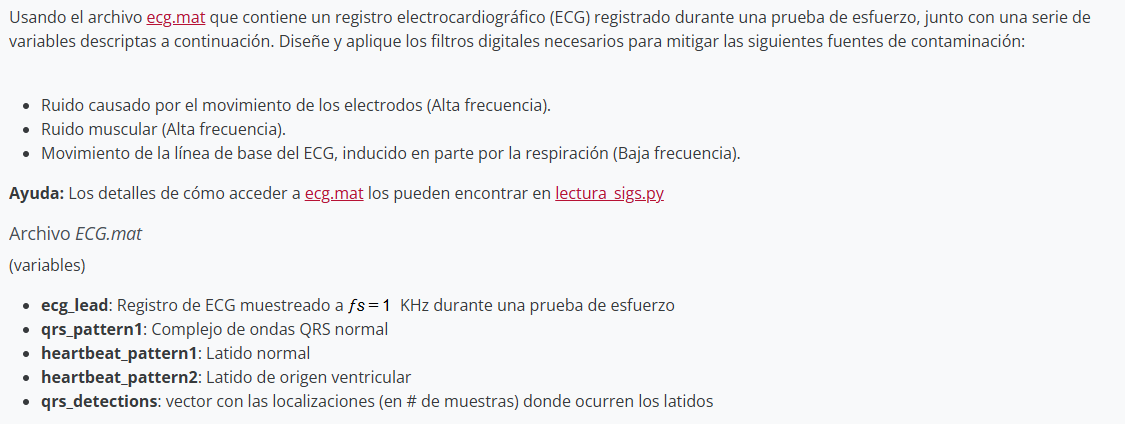
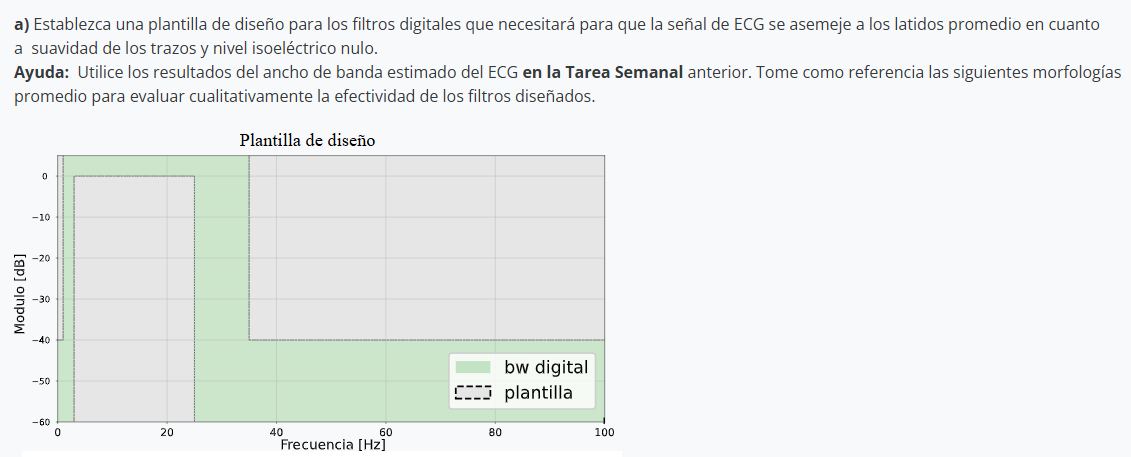
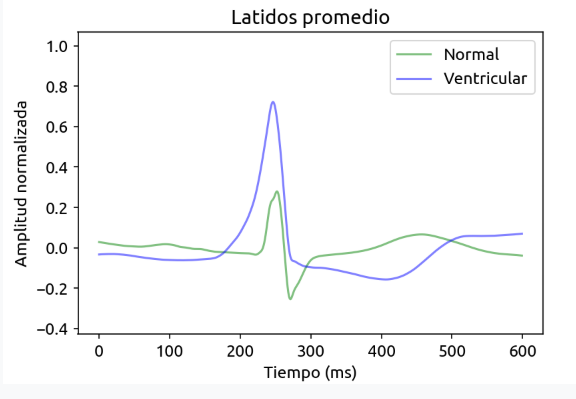
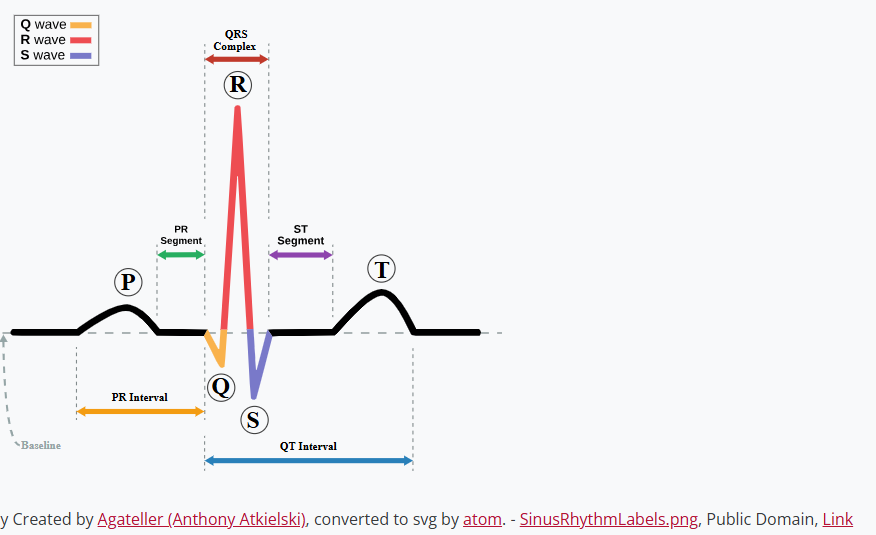
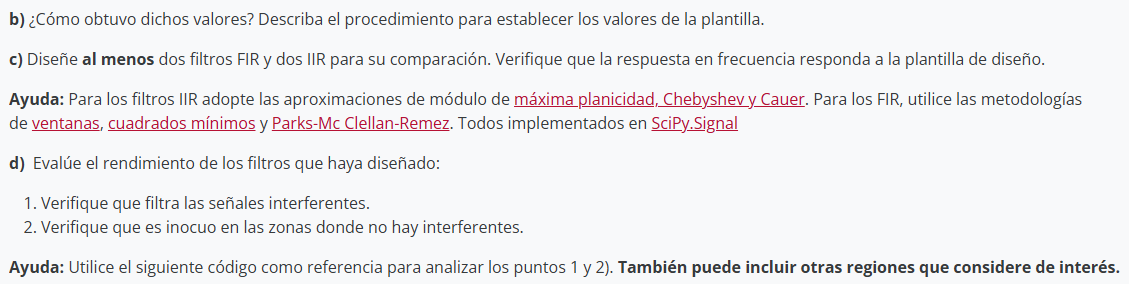

# Funciones

In [31]:
def plot_pzmap(z, p, *args, **kwargs):
    fig, ax = plt.subplots(*args, **kwargs)
    plt.scatter(np.real(z), np.imag(z), color='b', marker='o')
    plt.scatter(np.real(p), np.imag(p), color='r', marker='x')
    circle = plt.Circle((0,0), 1, fill=False)
    ax.add_patch(circle)
    ax.set_xlim((-1.1, 1.1))
    ax.set_ylim((-1.1, 1.1))

    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    plt.grid(True, which='both', ls='--')
    plt.title('Polos y Ceros del Filtro')
    plt.ylabel('Real')
    plt.xlabel('Imaginario')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    return fig, ax


# Señal

Señal de ECG con una frecuencia de muestreo de 1KHz tomada de un alumno. Presenta 2 zonas específicas denominadas heartbeat_pattern1 y heartbeat_pattern2

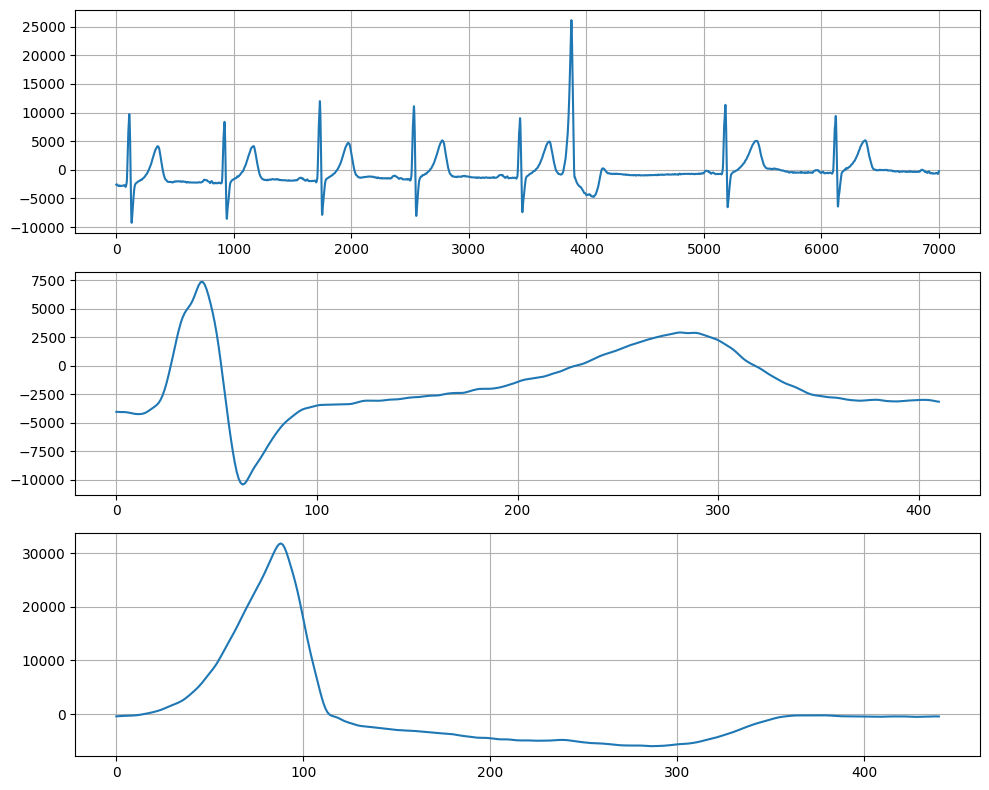

In [32]:
# Lectura de ECG #
fs = 1000 # Hz

# para listar las variables que hay en el archivo
#sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()
cant_muestras = len(ecg_one_lead)

hb_1 = mat_struct['heartbeat_pattern1'].flatten()
hb_2 = mat_struct['heartbeat_pattern2'].flatten()

plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.plot(ecg_one_lead[5000:12000])
plt.grid()

plt.subplot(3,1,2)
plt.plot(hb_1)
plt.grid()

plt.subplot(3,1,3)
plt.plot(hb_2)
plt.grid()

plt.tight_layout()
plt.show()


# Filtro IIR a realizar

Se realiza un filtro pasabanda con frecuencias de paso comprendidas entre 1Hz y 35Hz. Se rechazan frecuencias menores a .1Hz y mayores a 50Hz.
Estas frecuencias, según investigado, corresponden al rango útil de un ecg mientras que lo demás se puede considerar ruido por los electrodos, muscular, de respiración, etc.

El filtro a realizar es IIR

In [38]:
N = fs                # Cant Muestras
f0 = [1, 35]         # Freq de paso
f_cutoff = [.1, 50]    # Freq de stop

Att_pass_db = 1         # ATT en banda de paso. Tambien se conoce como ripple.
att_stop_db = 40        # ATT en banda de stop

sos_butt = sig.iirdesign(wp=f0, ws=f_cutoff, 
                       gpass=Att_pass_db, gstop=att_stop_db, fs=fs, 
                       analog=False, ftype='butter', output='sos')

sos_cauer = sig.iirdesign(wp=f0, ws=f_cutoff, 
                       gpass=Att_pass_db, gstop=att_stop_db, fs=fs, 
                       analog=False, ftype='cauer', output='sos')

sos_cheby1 = sig.iirdesign(wp=f0, ws=f_cutoff,    
                           gpass=Att_pass_db, gstop=att_stop_db, fs=fs,
                           analog=False, ftype='cheby1', output='sos')

print("Butter order:", sos_butt.shape[0]*2)
print("Cauer order:", sos_cauer.shape[0]*2)
print("Cheby order:", sos_cheby1.shape[0]*2)

Butter order: 30
Cauer order: 10
Cheby order: 14


# Gráficos de Filtro 
 Solo de Cauer

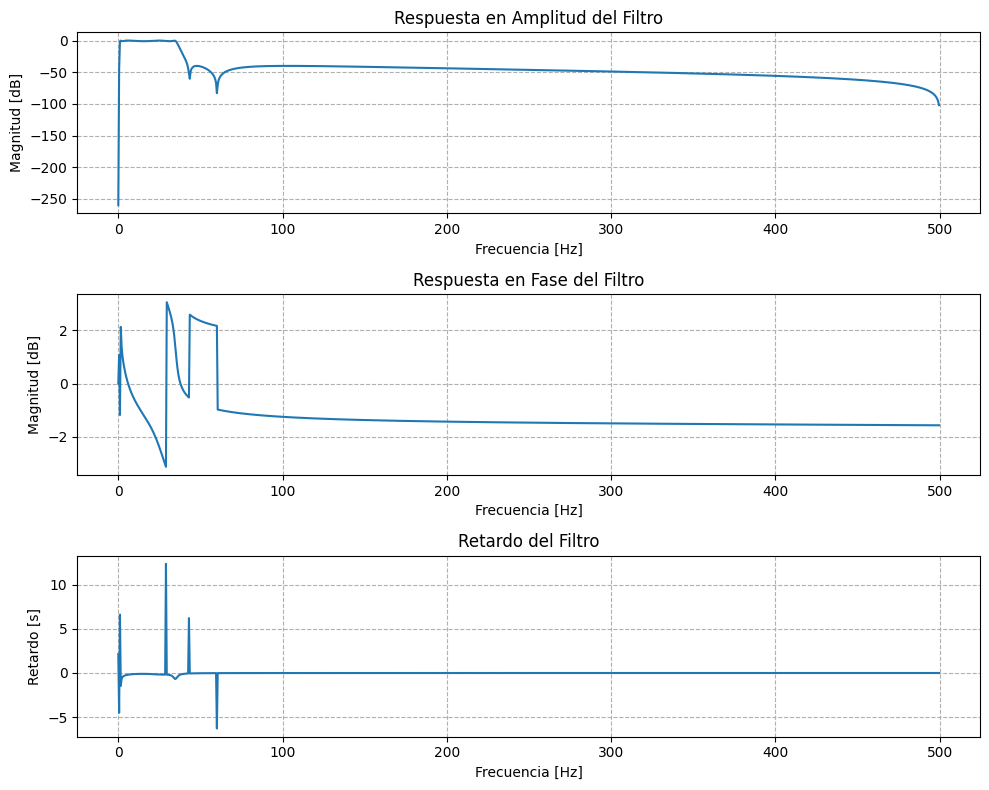

In [34]:
#w = np.concatenate( [np.logspace(-2, stop = np.log10(2), num = 250),
#					 np.linspace(2.1, stop = 34, num = 250),
#					 np.logspace(np.log10(34.5), stop = np.log10(2), num = 250),
#					 np.linspace(2.1, stop = 34, num = 250)])

w, H = sig.freqz_sos(sos_cauer, worN=N,  fs=fs)
# WorN: Omega o N. Le pasás el valor de mayor detalle para realizar el analisis del filtro.


plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.plot(w, 20*np.log10(np.maximum(abs(H), 1e-13)))
plt.title('Respuesta en Amplitud del Filtro')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-60, 5])

fase = np.angle(H) #np.unwrap(np.angle(tt))
plt.subplot(3,1,2)
plt.plot(w, fase)
plt.title('Respuesta en Fase del Filtro')
plt.ylabel('Magnitud [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-90, 90])

retardo = np.diff(fase)/np.diff(w)
retardo = np.append(retardo, retardo[-1])      # para que el vector tenga la misma longitud que w y fase.
plt.subplot(3,1,3)
plt.plot(w, retardo)
plt.title('Retardo del Filtro')
plt.ylabel('Retardo [s]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(True, which='both', ls='--')
#plt.ylim([-90, 90])
plt.tight_layout()
plt.show()

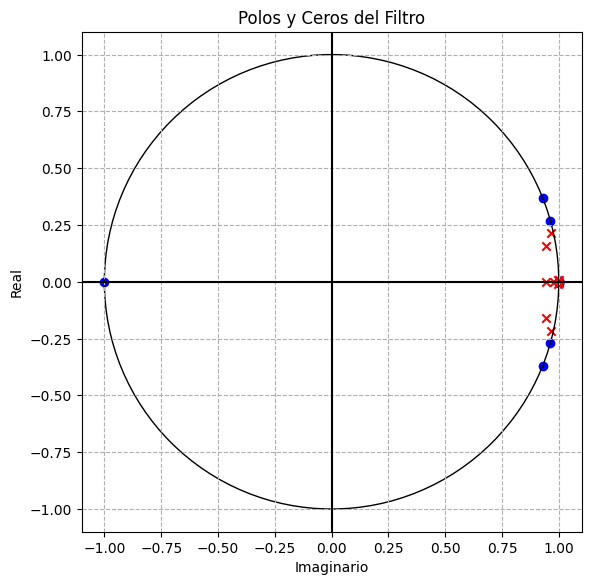

In [35]:
z, p, k = sig.sos2zpk(sos_cauer)

plot_pzmap(z,p, figsize=(6,6))
plt.show()

# Implementación de los Filtros en Regiones de interés

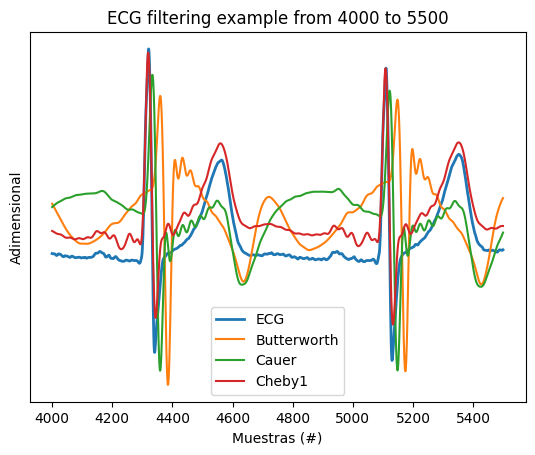

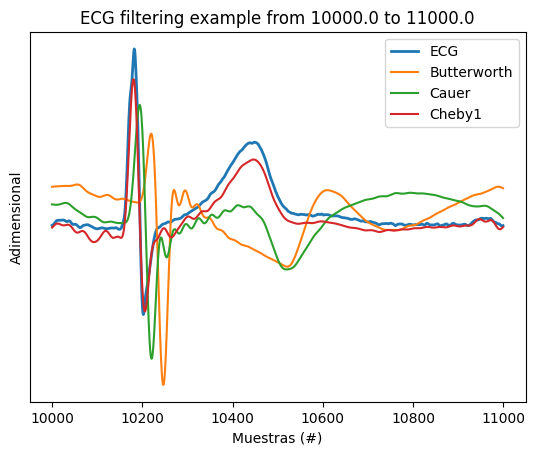

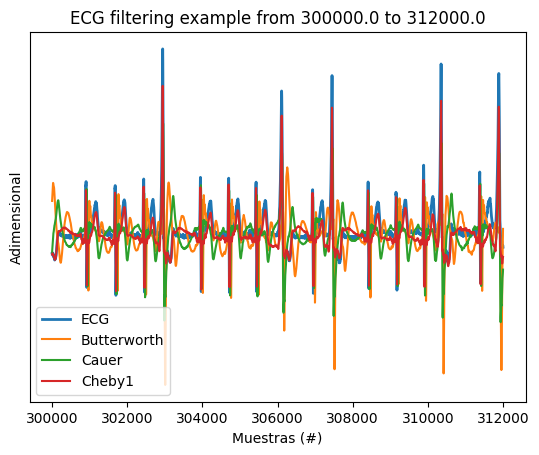

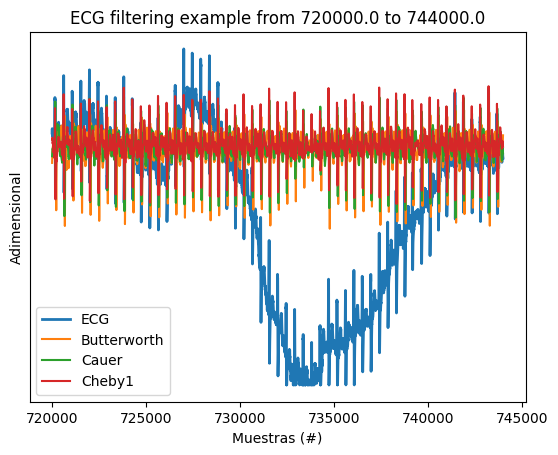

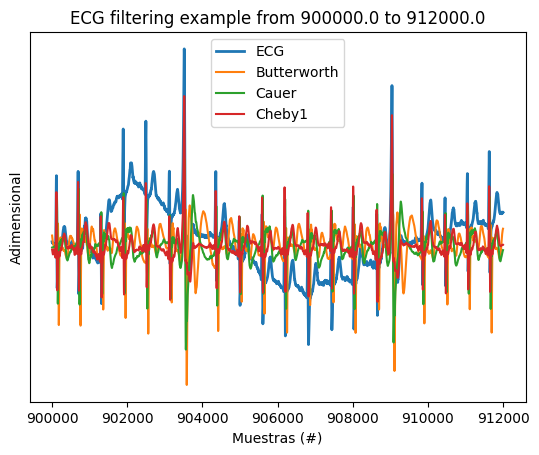

In [36]:
ECG_f_butt = sig.sosfilt(sos_butt, ecg_one_lead)    #ZI: Condiciones iniciales para el filtro.
ECG_f_cauer = sig.sosfilt(sos_cauer, ecg_one_lead) 
ECG_f_cheby1 = sig.sosfiltfilt(sos_cheby1, ecg_one_lead)

#%% Regiones de interés con ruido 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#%% Regiones de interés sin ruido 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

# Forward Backward filter


Utilizando la propiedad de espejado temporal
x(-t) --> X*(w)
Se puede obtener el complejo conjugado a la salida del filtro. 
Si el resultado del filtrado lo vuelvo a espejar y lo vuelvo a pasar por el filtro, se obtendría:

X --> X* --> FILTRO(T) --> X* T --> ESPEJO --> (X* T)* --> FILTRO(T) --> X T* T 

El resultado es X T* T. Eso es igual a X |T|^2
Se observa que la fase de T ya no tiene efecto en el filtrado, solo su módulo.

Se logra sos.sosfiltfilt

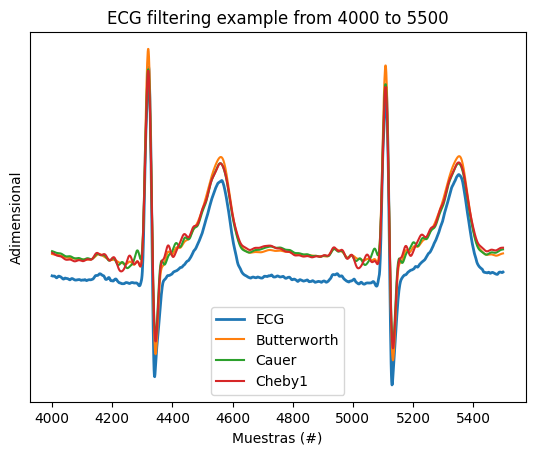

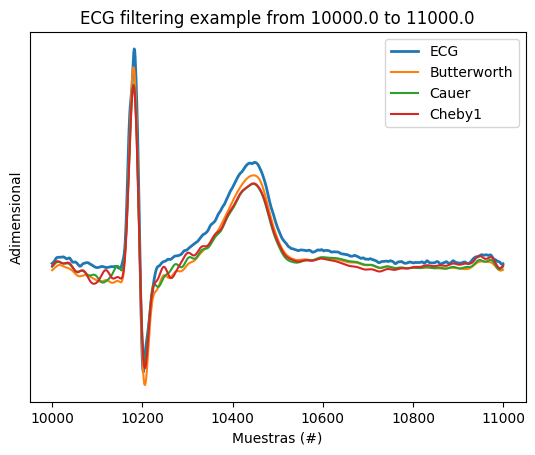

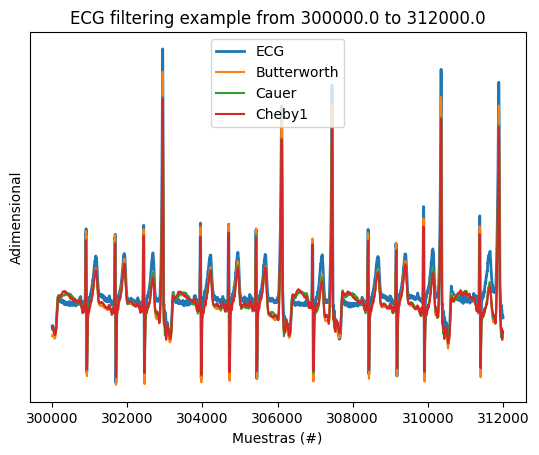

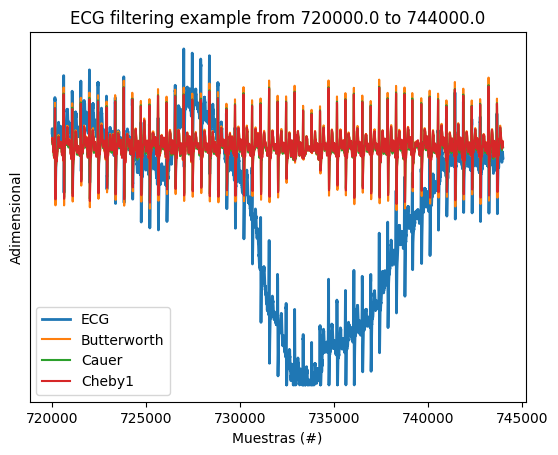

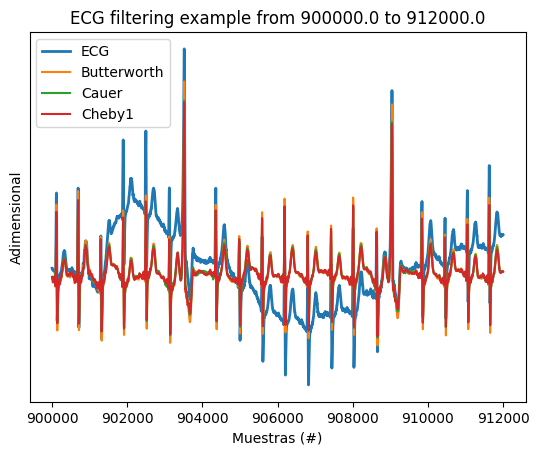

In [37]:
ECG_f_butt = sig.sosfiltfilt(sos_butt, ecg_one_lead)    #ZI: Condiciones iniciales para el filtro.
ECG_f_cauer = sig.sosfiltfilt(sos_cauer, ecg_one_lead) 
ECG_f_cheby1 = sig.sosfiltfilt(sos_cheby1, ecg_one_lead)

#%% Regiones de interés con ruido # 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#%% Regiones de interés sin ruido #
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()